# Chapter 2 — From vector addition to launch experiments

This self-contained notebook extends the first CUDA vector-addition example.
First write, compile, validate and display the original sum (Sections 1–7).
Then introduce a grid-stride loop and compare launch configurations (Sections 8–14).

**Question:** how does execution time change when the same additions are assigned
to different numbers of blocks and threads per block?

Use a GPU runtime in Google Colab (**Runtime → Change runtime type → GPU**).
CUDA C++ is compiled with `nvcc`; `%%writefile` creates ordinary source files.
No nvcc4jupyter, PyCUDA or CuPy dependency is required.
The plots and numerical discussion are generated from your GPU's measurements.
This delivered notebook has not been executed on a GPU; it contains no measured outputs.


## 1. Inspect the runtime

Colab executes the notebook on a remote Linux virtual machine. A leading `!` sends a command to that machine's shell. `nvidia-smi` reports the assigned GPU and driver information; `nvcc --version` reports the installed CUDA compiler. If either command fails, resolve the runtime setup before continuing.


In [1]:
!nvidia-smi
!nvcc --version


Mon Oct  5 17:09:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Create the source directory

The two source files will be stored together in `code/`, matching the directory layout used in the book.


In [2]:
!mkdir -p code


## 3. Write the kernel header

`%%writefile` is a built-in IPython cell command. It writes all subsequent lines of the cell to the named file, replacing that file if it exists. It does not compile or execute the C++ code.

Each thread computes one element. The `i < n` check protects array accesses in the partial final block. `extern "C"` preserves the kernel name for reuse by the Python interfaces discussed later in the book; it is not required to make the function run on the GPU.


In [3]:
%%writefile code/chapter02_vector_add_kernel.cuh
extern "C" __global__
void vector_add(const float *a, const float *b, float *c, int n)
{
    const int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        c[i] = a[i] + b[i];
    }
}


Writing code/chapter02_vector_add_kernel.cuh


## 4. Write the complete host program

The supplied source has been extended with an optional `--show` argument for printing the first 12 results. The vector addition and validation are unchanged. It allocates GPU buffers, copies the inputs, launches the kernel, waits for completion, retrieves and validates the result, and frees the buffers. `CUDA_CHECK` reports CUDA errors.

The launch uses 256 threads per block. For 100003 elements it creates 391 blocks, so 93 threads in the last block have no corresponding array element.


In [4]:
%%writefile code/chapter02_vector_add_cuda.cu
#include <cuda_runtime.h>
#include <cmath>
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <vector>
#include "chapter02_vector_add_kernel.cuh"

#define CUDA_CHECK(call) do {                                 \
    const cudaError_t status = (call);                        \
    if (status != cudaSuccess) {                              \
        std::fprintf(stderr, "%s:%d: %s\n", __FILE__, __LINE__, \
                     cudaGetErrorString(status));            \
        std::exit(EXIT_FAILURE);                             \
    }                                                        \
} while (0)

int main(int argc, char **argv)
{
    const bool show_results =
        argc > 1 && std::strcmp(argv[1], "--show") == 0;
    const int n = 100003;  // Not a multiple of the block size.
    const size_t bytes = size_t(n) * sizeof(float);
    std::vector<float> a(n), b(n), c(n);
    for (int i = 0; i < n; ++i) {
        a[i] = 0.25f * float(i % 101);
        b[i] = 0.50f * float(i % 37);
    }

    float *d_a = nullptr, *d_b = nullptr, *d_c = nullptr;
    CUDA_CHECK(cudaMalloc((void **)&d_a, bytes));
    CUDA_CHECK(cudaMalloc((void **)&d_b, bytes));
    CUDA_CHECK(cudaMalloc((void **)&d_c, bytes));
    CUDA_CHECK(cudaMemcpy(d_a, a.data(), bytes,
                          cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_b, b.data(), bytes,
                          cudaMemcpyHostToDevice));

    const int threads = 256;
    const int blocks = (n + threads - 1) / threads;
    vector_add<<<blocks, threads>>>(d_a, d_b, d_c, n);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());
    CUDA_CHECK(cudaMemcpy(c.data(), d_c, bytes,
                          cudaMemcpyDeviceToHost));

    bool correct = true;
    for (int i = 0; i < n; ++i) {
        const float expected = a[i] + b[i];
        const float tolerance = 1.e-6f * (1.0f + std::fabs(expected));
        if (!std::isfinite(c[i]) ||
            std::fabs(c[i] - expected) > tolerance) {
            std::fprintf(stderr, "Mismatch at index %d\n", i);
            correct = false;
            break;
        }
    }

    if (correct && show_results) {
        const int shown = (n < 12) ? n : 12;
        std::printf("\nVector addition: first %d of %d elements\n", shown, n);
        std::puts("     i          a[i]          b[i]       c[i] (GPU)");
        for (int i = 0; i < shown; ++i) {
            std::printf("%6d  %12.6f  %12.6f  %15.6f\n",
                        i, a[i], b[i], c[i]);
        }
        std::puts("c[i] contains the actual result copied from GPU memory.");
        std::puts("Validation checks all elements, not only those displayed.");
    }

    CUDA_CHECK(cudaFree(d_a));
    CUDA_CHECK(cudaFree(d_b));
    CUDA_CHECK(cudaFree(d_c));
    std::puts(correct ? "Validation passed" : "Validation failed");
    return correct ? EXIT_SUCCESS : EXIT_FAILURE;
}


Writing code/chapter02_vector_add_cuda.cu


## 5. Compile

- `nvcc` coordinates compilation of the CPU and GPU portions.
- `-O2` requests optimization level 2 for **host code**. GPU code is normally optimized independently.
- `-std=c++14` explicitly selects the C++14 language standard, which is sufficient for this example.
- `-o vector_add_cuda` names the executable.

Proceed to the execution cell only if compilation succeeds. Successful compilation may produce no output. If you change a source cell, rerun that cell and compile again before executing the program.


In [5]:
!nvcc -O2 -std=c++14 code/chapter02_vector_add_cuda.cu -o vector_add_cuda


## 6. Run and validate

The prefix `./` identifies the executable in the current directory. On success, the program prints `Validation passed`. This is the expected message, not a result already obtained in this notebook. A failed CUDA call or numerical mismatch is reported as an error.


In [6]:
!./vector_add_cuda


Validation passed


## 7. Display the computed sum

Run the following cell to display the first 12 entries of the input vectors `a`, `b`, and the result `c`. The `--show` option reruns the CUDA program and prints the actual values copied back from the GPU; it does not recompute the displayed sum in Python. All 100003 entries are still validated.

After updating the program, rerun its `%%writefile` cell and the compilation cell before using this option.


In [7]:
!./vector_add_cuda --show



Vector addition: first 12 of 100003 elements
     i          a[i]          b[i]       c[i] (GPU)
     0      0.000000      0.000000         0.000000
     1      0.250000      0.500000         0.750000
     2      0.500000      1.000000         1.500000
     3      0.750000      1.500000         2.250000
     4      1.000000      2.000000         3.000000
     5      1.250000      2.500000         3.750000
     6      1.500000      3.000000         4.500000
     7      1.750000      3.500000         5.250000
     8      2.000000      4.000000         6.000000
     9      2.250000      4.500000         6.750000
    10      2.500000      5.000000         7.500000
    11      2.750000      5.500000         8.250000
c[i] contains the actual result copied from GPU memory.
Validation checks all elements, not only those displayed.
Validation passed


## 8. Reuse the author's timer

The supplied `Timing.zip` is retained unchanged in `original/`.
The GPU class below retains `TimingGPU`, `StartCounter()`, `StartCounterFlags()`
and `GetCounter()`. The notebook adaptation adds its own header include, checks
CUDA errors, creates and reuses events, and releases them in the destructor.
Copying the owning timer is disabled. `GetCounter()` waits for the stop event
on the default stream and returns milliseconds. All measured kernels use that stream.

The original CPU timer is Windows-specific and is not needed here.
We time GPU work only: no CPU/GPU speedup will be claimed.
The support implementation is provided for reproducibility; you can run these cells
without studying event management yet.


In [8]:
from pathlib import Path
import base64
Path('original').mkdir(exist_ok=True)
Path('original/Timing.zip').write_bytes(base64.b64decode('UEsDBBQACAgAAEAuRV0AAAAAAAAAAAAAAAAUAAAAVGltaW5nL1RpbWluZ0NQVS5jcHAvKioqKioqKioqKioqKiovDQovKiBUSU1JTkcgQ1BVICovDQovKioqKioqKioqKioqKiovDQoNCiNpbmNsdWRlIDx3aW5kb3dzLmg+DQojaW5jbHVkZSA8aW9zdHJlYW0+DQoNCnN0cnVjdCBQcml2YXRlVGltaW5nQ1BVIHsNCglkb3VibGUJUENGcmVxOw0KCV9faW50NjQgQ291bnRlclN0YXJ0Ow0KfTsNCgkJCQ0KLy8gLS0tIERlZmF1bHQgY29uc3RydWN0b3INClRpbWluZ0NQVTo6VGltaW5nQ1BVKCkgeyBwcml2YXRlVGltaW5nQ1BVID0gbmV3IFByaXZhdGVUaW1pbmdDUFU7ICgqcHJpdmF0ZVRpbWluZ0NQVSkuUENGcmVxID0gMC4wOyAoKnByaXZhdGVUaW1pbmdDUFUpLkNvdW50ZXJTdGFydCA9IDA7IH0NCg0KLy8gLS0tIERlZmF1bHQgZGVzdHJ1Y3Rvcg0KVGltaW5nQ1BVOjp+VGltaW5nQ1BVKCkgeyB9DQoNCi8vIC0tLSBTdGFydHMgdGhlIHRpbWluZw0Kdm9pZCBUaW1pbmdDUFU6OlN0YXJ0Q291bnRlcigpDQp7DQoJTEFSR0VfSU5URUdFUiBsaTsNCglpZighUXVlcnlQZXJmb3JtYW5jZUZyZXF1ZW5jeSgmbGkpKSBzdGQ6OmNvdXQgPDwgIlF1ZXJ5UGVyZm9ybWFuY2VGcmVxdWVuY3kgZmFpbGVkIVxuIjsNCg0KCSgqcHJpdmF0ZVRpbWluZ0NQVSkuUENGcmVxID0gZG91YmxlKGxpLlF1YWRQYXJ0KS8xMDAwLjA7DQoNCglRdWVyeVBlcmZvcm1hbmNlQ291bnRlcigmbGkpOw0KCSgqcHJpdmF0ZVRpbWluZ0NQVSkuQ291bnRlclN0YXJ0ID0gbGkuUXVhZFBhcnQ7DQp9DQoNCi8vIC0tLSBHZXRzIHRoZSB0aW1pbmcgY291bnRlciBpbiBtcw0KZG91YmxlIFRpbWluZ0NQVTo6R2V0Q291bnRlcigpDQp7DQoJTEFSR0VfSU5URUdFUiBsaTsNCglRdWVyeVBlcmZvcm1hbmNlQ291bnRlcigmbGkpOw0KCXJldHVybiBkb3VibGUobGkuUXVhZFBhcnQtKCpwcml2YXRlVGltaW5nQ1BVKS5Db3VudGVyU3RhcnQpLygqcHJpdmF0ZVRpbWluZ0NQVSkuUENGcmVxOw0KfQ0KDQoNClBLBwh2YDTntgMAALYDAABQSwMEFAAICAAAQC5FXQAAAAAAAAAAAAAAABIAAABUaW1pbmcvVGltaW5nQ1BVLmgvLyAxIG1pY3JvLXNlY29uZCBhY2N1cmFjeQ0KLy8gUmV0dXJucyB0aGUgdGltZSBpbiBzZWNvbmRzDQoNCiNpZm5kZWYgX19USU1JTkdDUFVfSF9fDQojZGVmaW5lIF9fVElNSU5HQ1BVX0hfXw0KDQpzdHJ1Y3QgUHJpdmF0ZVRpbWluZ0NQVTsgDQoNCmNsYXNzIFRpbWluZ0NQVQ0Kew0KCXByaXZhdGU6DQoJCVByaXZhdGVUaW1pbmdDUFUgKnByaXZhdGVUaW1pbmdDUFU7DQoNCglwdWJsaWM6DQoJCQkNCgkJVGltaW5nQ1BVKCk7DQoNCgkJflRpbWluZ0NQVSgpOw0KDQoJCXZvaWQgU3RhcnRDb3VudGVyKCk7DQoNCgkJZG91YmxlIEdldENvdW50ZXIoKTsNCg0KCX07IC8vIFRpbWluZ0NQVSBjbGFzcw0KDQoNCiNlbmRpZiANCg0KDQpQSwcIkarVUWgBAABoAQAAUEsDBBQACAgAAEAuRV0AAAAAAAAAAAAAAAATAAAAVGltaW5nL1RpbWluZ0dQVS5jdS8qKioqKioqKioqKioqKi8NCi8qIFRJTUlORyBHUFUgKi8NCi8qKioqKioqKioqKioqKi8NCg0KI2luY2x1ZGUgPGN1ZGEuaD4NCiNpbmNsdWRlIDxjdWRhX3J1bnRpbWUuaD4NCg0Kc3RydWN0IFByaXZhdGVUaW1pbmdHUFUgew0KCWN1ZGFFdmVudF90CQlzdGFydDsNCgljdWRhRXZlbnRfdAkJc3RvcDsNCn07DQoNCi8vIGRlZmF1bHQgY29uc3RydWN0b3INClRpbWluZ0dQVTo6VGltaW5nR1BVKCkgeyBwcml2YXRlVGltaW5nR1BVID0gbmV3IFByaXZhdGVUaW1pbmdHUFU7IH0NCg0KLy8gZGVmYXVsdCBkZXN0cnVjdG9yDQpUaW1pbmdHUFU6On5UaW1pbmdHUFUoKSB7IH0NCg0Kdm9pZCBUaW1pbmdHUFU6OlN0YXJ0Q291bnRlcigpDQp7DQoJY3VkYUV2ZW50Q3JlYXRlKCYoKCpwcml2YXRlVGltaW5nR1BVKS5zdGFydCkpOw0KCWN1ZGFFdmVudENyZWF0ZSgmKCgqcHJpdmF0ZVRpbWluZ0dQVSkuc3RvcCkpOw0KCWN1ZGFFdmVudFJlY29yZCgoKnByaXZhdGVUaW1pbmdHUFUpLnN0YXJ0LDApOw0KfQ0KDQp2b2lkIFRpbWluZ0dQVTo6U3RhcnRDb3VudGVyRmxhZ3MoKQ0Kew0KCWludCBldmVudGZsYWdzID0gY3VkYUV2ZW50QmxvY2tpbmdTeW5jOw0KDQoJY3VkYUV2ZW50Q3JlYXRlV2l0aEZsYWdzKCYoKCpwcml2YXRlVGltaW5nR1BVKS5zdGFydCksZXZlbnRmbGFncyk7DQoJY3VkYUV2ZW50Q3JlYXRlV2l0aEZsYWdzKCYoKCpwcml2YXRlVGltaW5nR1BVKS5zdG9wKSxldmVudGZsYWdzKTsNCgljdWRhRXZlbnRSZWNvcmQoKCpwcml2YXRlVGltaW5nR1BVKS5zdGFydCwwKTsNCn0NCg0KLy8gR2V0cyB0aGUgY291bnRlciBpbiBtcw0KZmxvYXQgVGltaW5nR1BVOjpHZXRDb3VudGVyKCkNCnsNCglmbG9hdAl0aW1lOw0KCWN1ZGFFdmVudFJlY29yZCgoKnByaXZhdGVUaW1pbmdHUFUpLnN0b3AsIDApOw0KCWN1ZGFFdmVudFN5bmNocm9uaXplKCgqcHJpdmF0ZVRpbWluZ0dQVSkuc3RvcCk7DQoJY3VkYUV2ZW50RWxhcHNlZFRpbWUoJnRpbWUsKCpwcml2YXRlVGltaW5nR1BVKS5zdGFydCwoKnByaXZhdGVUaW1pbmdHUFUpLnN0b3ApOw0KCXJldHVybiB0aW1lOw0KfQ0KDQpQSwcI6hk4aScEAAAnBAAAUEsDBBQACAgAAEAuRV0AAAAAAAAAAAAAAAAUAAAAVGltaW5nL1RpbWluZ0dQVS5jdWgjaWZuZGVmIF9fVElNSU5HX0NVSF9fDQojZGVmaW5lIF9fVElNSU5HX0NVSF9fDQoNCi8qKioqKioqKioqKioqKi8NCi8qIFRJTUlORyBHUFUgKi8NCi8qKioqKioqKioqKioqKi8NCg0KLy8gRXZlbnRzIGFyZSBhIHBhcnQgb2YgQ1VEQSBBUEkgYW5kIHByb3ZpZGUgYSBzeXN0ZW0gaW5kZXBlbmRlbnQgd2F5IHRvIG1lYXN1cmUgZXhlY3V0aW9uIHRpbWVzIG9uIENVREEgZGV2aWNlcyB3aXRoIGFwcHJveGltYXRlbHkgMC41IA0KLy8gbWljcm9zZWNvbmQgcHJlY2lzaW9uLg0KDQpzdHJ1Y3QgUHJpdmF0ZVRpbWluZ0dQVTsNCg0KY2xhc3MgVGltaW5nR1BVDQp7DQoJcHJpdmF0ZToNCgkJUHJpdmF0ZVRpbWluZ0dQVSAqcHJpdmF0ZVRpbWluZ0dQVTsNCg0KCXB1YmxpYzoNCgkJCQ0KCQlUaW1pbmdHUFUoKTsNCg0KCQl+VGltaW5nR1BVKCk7DQoNCgkJdm9pZCBTdGFydENvdW50ZXIoKTsNCgkJdm9pZCBTdGFydENvdW50ZXJGbGFncygpOw0KDQoJCWZsb2F0IEdldENvdW50ZXIoKTsNCg0KfTsgLy8gVGltaW5nQ1BVIGNsYXNzDQoNCiNlbmRpZiANClBLBwijXLdvGwIAABsCAABQSwECFAAUAAgIAABALkVddmA057YDAAC2AwAAFAAAAAAAAAAAAAAAAAAAAAAAVGltaW5nL1RpbWluZ0NQVS5jcHBQSwECFAAUAAgIAABALkVdkarVUWgBAABoAQAAEgAAAAAAAAAAAAAAAAD4AwAAVGltaW5nL1RpbWluZ0NQVS5oUEsBAhQAFAAICAAAQC5FXeoZOGknBAAAJwQAABMAAAAAAAAAAAAAAAAAoAUAAFRpbWluZy9UaW1pbmdHUFUuY3VQSwECFAAUAAgIAABALkVdo1y3bxsCAAAbAgAAFAAAAAAAAAAAAAAAAAAICgAAVGltaW5nL1RpbWluZ0dQVS5jdWhQSwUGAAAAAAQABAAFAQAAZQwAAAAA'))
print('Original Timing.zip preserved in original/.')


Original Timing.zip preserved in original/.


In [9]:
%%writefile code/cuda_check.cuh
#ifndef BOOK_CUDA_CHECK_CUH
#define BOOK_CUDA_CHECK_CUH
#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#define CUDA_CHECK(call) do { \
    const cudaError_t status_ = (call); \
    if (status_ != cudaSuccess) { \
        std::fprintf(stderr, "%s:%d: %s\n", __FILE__, __LINE__, \
                     cudaGetErrorString(status_)); \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)
#endif


Writing code/cuda_check.cuh


In [10]:
%%writefile code/TimingGPU.cuh
#ifndef BOOK_TIMING_GPU_CUH
#define BOOK_TIMING_GPU_CUH
// Adapted from the author's Timing.zip for repeated notebook experiments.
// Same public timing methods; errors checked and resources released.
struct PrivateTimingGPU;
class TimingGPU {
    PrivateTimingGPU *privateTimingGPU;
    void Start(unsigned int flags);
public:
    TimingGPU();
    ~TimingGPU();
    TimingGPU(const TimingGPU&) = delete;
    TimingGPU& operator=(const TimingGPU&) = delete;
    void StartCounter();
    void StartCounterFlags();
    float GetCounter(); // milliseconds; waits for the stop event
};
#endif


Writing code/TimingGPU.cuh


In [11]:
%%writefile code/TimingGPU.cu
#include "TimingGPU.cuh"
#include "cuda_check.cuh"

struct PrivateTimingGPU {
    cudaEvent_t start, stop;
    unsigned int flags;
    bool started;
};

TimingGPU::TimingGPU() : privateTimingGPU(new PrivateTimingGPU{}) {
    CUDA_CHECK(cudaEventCreate(&privateTimingGPU->start));
    CUDA_CHECK(cudaEventCreate(&privateTimingGPU->stop));
}

TimingGPU::~TimingGPU() {
    CUDA_CHECK(cudaEventDestroy(privateTimingGPU->start));
    CUDA_CHECK(cudaEventDestroy(privateTimingGPU->stop));
    delete privateTimingGPU;
}

void TimingGPU::Start(unsigned int flags) {
    if (flags != privateTimingGPU->flags) {
        CUDA_CHECK(cudaEventDestroy(privateTimingGPU->start));
        CUDA_CHECK(cudaEventDestroy(privateTimingGPU->stop));
        CUDA_CHECK(cudaEventCreateWithFlags(&privateTimingGPU->start, flags));
        CUDA_CHECK(cudaEventCreateWithFlags(&privateTimingGPU->stop, flags));
        privateTimingGPU->flags = flags;
    }
    CUDA_CHECK(cudaEventRecord(privateTimingGPU->start, 0));
    privateTimingGPU->started = true;
}

void TimingGPU::StartCounter() { Start(cudaEventDefault); }
void TimingGPU::StartCounterFlags() { Start(cudaEventBlockingSync); }

float TimingGPU::GetCounter() {
    if (!privateTimingGPU->started) {
        std::fprintf(stderr, "Call StartCounter before GetCounter.\n");
        std::exit(EXIT_FAILURE);
    }
    CUDA_CHECK(cudaEventRecord(privateTimingGPU->stop, 0));
    CUDA_CHECK(cudaEventSynchronize(privateTimingGPU->stop));
    float elapsed_ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&elapsed_ms, privateTimingGPU->start,
                                  privateTimingGPU->stop));
    return elapsed_ms;
}


Writing code/TimingGPU.cu


## 9. Let each thread process more than one element

With G blocks of B threads, the total thread count and stride are G×B.
Global thread t visits t, t+G×B, t+2G×B, and so on, while the index is less than N.
Every valid output element is written once, even with a very small launch.
The additions remain the same; a smaller grid gives more loop iterations to each thread.

Read this kernel before running the experiment. For a toy vector of 23 elements
and eight total threads, predict which elements thread zero and thread seven update.


In [12]:
%%writefile code/chapter02_grid_stride.cuh
#ifndef BOOK_GRID_STRIDE_CUH
#define BOOK_GRID_STRIDE_CUH
__global__ void vector_add_grid_stride(const float *a, const float *b,
                                      float *c, int n) {
    for (int i = blockIdx.x * blockDim.x + threadIdx.x;
         i < n; i += blockDim.x * gridDim.x) {
        c[i] = a[i] + b[i];
    }
}
#endif


Writing code/chapter02_grid_stride.cuh


In [13]:
toy_n, toy_threads = 23, 8
for thread in range(toy_threads):
    print(f'Thread {thread}: {list(range(thread, toy_n, toy_threads))}')
visited = [i for t in range(toy_threads) for i in range(t, toy_n, toy_threads)]
assert sorted(visited) == list(range(toy_n))


Thread 0: [0, 8, 16]
Thread 1: [1, 9, 17]
Thread 2: [2, 10, 18]
Thread 3: [3, 11, 19]
Thread 4: [4, 12, 20]
Thread 5: [5, 13, 21]
Thread 6: [6, 14, 22]
Thread 7: [7, 15]


## 10. Run the controlled experiments

| Experiment | Held fixed | Changed | Question |
|---|---|---|---|
| A. Small grids | N = 1,048,579 and inputs | Blocks and threads; includes matched total thread counts | Can independent blocks help? |
| B. Grid sweep | Same N; 256 threads per block | Number of blocks | Does adding blocks keep reducing time? |
| C. Block partition | Same N; 1024×M total threads | Threads per block (32 to 512); blocks adjusted | Does grouping the same threads matter? |
| D. Problem size | Addition and 256 threads per block | Four vector lengths and four grid strategies | Is the conclusion specific to large arrays? |

M is the number of SMs reported by the assigned GPU. A grid of M blocks does **not**
guarantee one block on every SM. Blocks within one launch are distributed by hardware.

**Measurement scope.** Input construction, memory allocation, CPU–GPU transfers,
validation and printing are outside the timed intervals. Every configuration is
validated against all CPU reference values, with the output first filled with NaNs
to catch unwritten elements. The lengths are deliberately not multiples of block size.
Two warm-up launches precede pilot timing. A pilot chooses 1–200 repeated launches
per batch, targeting about 5 ms; the cap means short batches may be shorter.
Seven trials are recorded per configuration. The order of configurations is shuffled
in each trial to reduce ordering bias. One untimed launch refreshes the data before
each trial. Event times divided by repetitions are summarized with the median and
interquartile range. Error bars are **not** confidence intervals.

These are repeated-array timings: caches can affect the results. For tiny kernels,
idle gaps between host submissions may also enter the interval. We do not infer
actual SM assignment, achieved occupancy, or isolated memory latency from these timings.

The host code below implements the protocol. You can execute it as supplied and
focus first on the four plots. Defaults normally give a short run; runtime varies
with the assigned GPU and other activity.


In [14]:
%%writefile code/chapter02_launch_experiment.cu
#include "cuda_check.cuh"
#include "TimingGPU.cuh"
#include "chapter02_grid_stride.cuh"
#include <algorithm>
#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <random>
#include <set>
#include <string>
#include <vector>

struct Config { int blocks, threads, repeats = 1; };
const int trials = 7;
const double target_batch_ms = 5.0;
const int max_repeats = 200;

struct Data {
    int n;
    size_t bytes;
    std::vector<float> a, b, c;
    float *da = nullptr, *db = nullptr, *dc = nullptr;
    explicit Data(int count) : n(count), bytes(size_t(n)*sizeof(float)),
                               a(n), b(n), c(n) {
        for (int i=0; i<n; ++i) {
            a[i] = 0.25f * float(i%101);
            b[i] = 0.50f * float(i%37);
        }
        CUDA_CHECK(cudaMalloc((void**)&da, bytes));
        CUDA_CHECK(cudaMalloc((void**)&db, bytes));
        CUDA_CHECK(cudaMalloc((void**)&dc, bytes));
        CUDA_CHECK(cudaMemcpy(da,a.data(),bytes,cudaMemcpyHostToDevice));
        CUDA_CHECK(cudaMemcpy(db,b.data(),bytes,cudaMemcpyHostToDevice));
    }
    ~Data() {
        CUDA_CHECK(cudaFree(da)); CUDA_CHECK(cudaFree(db));
        CUDA_CHECK(cudaFree(dc));
    }
    void launch(const Config& c) {
        vector_add_grid_stride<<<c.blocks,c.threads>>>(da,db,dc,n);
    }
    void validate(const Config& cfg) {
        // NaNs reveal any output not written, including partial final blocks.
        CUDA_CHECK(cudaMemset(dc,0xff,bytes));
        launch(cfg);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());
        CUDA_CHECK(cudaMemcpy(c.data(),dc,bytes,cudaMemcpyDeviceToHost));
        for (int i=0; i<n; ++i) {
            float ref=a[i]+b[i];
            if (!std::isfinite(c[i]) || std::fabs(c[i]-ref)>1.e-6f*(1.f+std::fabs(ref))) {
                std::fprintf(stderr,"Validation failed: N=%d, blocks=%d, threads=%d, i=%d\n",
                             n,cfg.blocks,cfg.threads,i);
                std::exit(EXIT_FAILURE);
            }
        }
    }
};

double batch(Data& data, const Config& cfg, TimingGPU& timer) {
    timer.StartCounter();
    for (int k=0; k<cfg.repeats; ++k) data.launch(cfg);
    CUDA_CHECK(cudaGetLastError());
    return timer.GetCounter();
}

void experiment(const std::string& name, int n, std::vector<Config> configs,
                const cudaDeviceProp& prop, std::ofstream& csv, std::mt19937& rng) {
    std::set<std::pair<int,int>> seen;
    configs.erase(std::remove_if(configs.begin(),configs.end(),[&](const Config& c) {
        return c.threads>prop.maxThreadsPerBlock || c.blocks>prop.maxGridSize[0]
               || !seen.insert({c.blocks,c.threads}).second;
    }), configs.end());
    Data data(n);
    TimingGPU timer;
    for (auto& cfg: configs) {
        data.validate(cfg);
        for (int warm=0; warm<2; ++warm) data.launch(cfg);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());
        const double pilot_ms = batch(data,cfg,timer);
        // Clamp before conversion so even a zero-resolution pilot is safe.
        cfg.repeats = int(std::min(double(max_repeats),
                             std::max(1.0,std::ceil(target_batch_ms/std::max(pilot_ms,0.001)))));
    }
    // Revisit every configuration once per trial, shuffling the order.
    for (int trial=0; trial<trials; ++trial) {
        std::shuffle(configs.begin(),configs.end(),rng);
        for (const auto& cfg: configs) {
            data.launch(cfg); // untimed refresh after switching configuration
            CUDA_CHECK(cudaGetLastError());
            CUDA_CHECK(cudaDeviceSynchronize());
            const double total_ms = batch(data,cfg,timer);
            if (!(total_ms>0) || !std::isfinite(total_ms)) {
                std::fprintf(stderr,"Invalid timer result.\n"); std::exit(EXIT_FAILURE);
            }
            csv<<name<<','<<n<<','<<cfg.blocks<<','<<cfg.threads<<','
               <<size_t(cfg.blocks)*cfg.threads<<','<<trial<<','<<cfg.repeats<<','
               <<total_ms/cfg.repeats<<','<<total_ms<<'\n';
        }
    }
    csv.flush();
    std::cout<<name<<": N="<<n<<", "<<configs.size()
             <<" configurations, all outputs validated.\n"<<std::flush;
}

int main() {
    CUDA_CHECK(cudaSetDevice(0));
    cudaDeviceProp prop{};
    CUDA_CHECK(cudaGetDeviceProperties(&prop,0));
    int driver=0,runtime=0;
    CUDA_CHECK(cudaDriverGetVersion(&driver));
    CUDA_CHECK(cudaRuntimeGetVersion(&runtime));
    const int sm=prop.multiProcessorCount;
    std::cout<<"GPU: "<<prop.name<<"; SMs: "<<sm<<"; L2 bytes: "<<prop.l2CacheSize<<'\n';
    std::ofstream meta("device.json");
    if (!meta) { std::cerr<<"Cannot create device.json\n"; return EXIT_FAILURE; }
    meta<<"{\n\"gpu\": \""<<prop.name<<"\",\n\"sms\": "<<sm
        <<",\n\"compute_major\": "<<prop.major<<",\n\"compute_minor\": "<<prop.minor
        <<",\n\"l2_bytes\": "<<prop.l2CacheSize<<",\n\"driver\": "<<driver
        <<",\n\"runtime\": "<<runtime<<",\n\"toolkit\": "<<CUDART_VERSION
        <<",\n\"trials\": "<<trials<<",\n\"seed\": 20261005,\n\"target_batch_ms\": "
        <<target_batch_ms<<",\n\"max_repeats\": "<<max_repeats<<"\n}\n";
    std::ofstream csv("launch_results.csv");
    if (!csv) { std::cerr<<"Cannot create launch_results.csv\n"; return EXIT_FAILURE; }
    csv<<"experiment,n,blocks,threads,total_threads,trial,repeats,mean_ms,batch_ms\n";
    csv<<std::setprecision(10);
    std::mt19937 rng(20261005);
    const int n=1048579;
    experiment("A_small_grids",n,{{1,32},{1,64},{2,32},{1,256},{8,32},
               {sm,256},{4*sm,256},{(n+255)/256,256}},prop,csv,rng);
    std::set<int> counts={1,2,4,8,std::max(1,sm/4),std::max(1,sm/2),sm,2*sm,4*sm,8*sm,16*sm};
    std::vector<Config> sweep;
    for (int blocks:counts) sweep.push_back({blocks,256});
    experiment("B_grid_sweep",n,sweep,prop,csv,rng);
    std::vector<Config> partition;
    const int total_threads=sm*1024;
    for (int threads:{32,64,128,256,512}) partition.push_back({total_threads/threads,threads});
    experiment("C_fixed_threads",n,partition,prop,csv,rng);
    for (int size:{4099,65539,1048579,8388611})
        experiment("D_problem_size",size,{{1,256},{sm,256},{4*sm,256},{(size+255)/256,256}},
                   prop,csv,rng);
    std::cout<<"Wrote launch_results.csv and device.json.\n";
}


Writing code/chapter02_launch_experiment.cu


Compile both the experiment and the timer implementation. `-Icode` selects the
header directory. As before, `-O2` controls host optimization and `-std=c++14`
selects the language standard. The shell stops if compilation fails.


In [15]:
%%bash
set -eu
rm -f launch_experiment
nvcc -O2 -std=c++14 -Icode code/chapter02_launch_experiment.cu code/TimingGPU.cu -o launch_experiment


In [16]:
import subprocess
from pathlib import Path
for name in ['launch_results.csv', 'device.json']:
    Path(name).unlink(missing_ok=True)
subprocess.run(['./launch_experiment'], check=True)
print('Benchmark completed successfully. Continue to the analysis cells.')


Benchmark completed successfully. Continue to the analysis cells.


## 11. Load the measurements and draw the plots

The following support module reads the actual CSV output. It computes the median
of the seven trial means, saves figures as PNG and PDF, and writes a numerical
commentary. It does not create substitute or simulated performance data.


In [17]:
%%writefile code/analyze_launch.py
"""Summarize actual CSV measurements; never generates benchmark data."""
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_results():
    meta = json.loads(Path('device.json').read_text())
    raw = pd.read_csv('launch_results.csv')
    keys = ['experiment', 'n', 'blocks', 'threads', 'total_threads']
    assert np.isfinite(raw.mean_ms).all() and (raw.mean_ms > 0).all()
    summary = raw.groupby(keys, as_index=False).agg(
        median_ms=('mean_ms','median'),
        q25_ms=('mean_ms',lambda x: x.quantile(.25)),
        q75_ms=('mean_ms',lambda x: x.quantile(.75)),
        trials=('mean_ms','size'), repeats=('repeats','first'))
    assert (summary.trials == meta['trials']).all()
    summary['effective_GB_s'] = 12 * summary.n / (summary.median_ms * 1e6)
    Path('results').mkdir(exist_ok=True)
    summary.to_csv('results/launch_summary.csv', index=False)
    print(f"GPU: {meta['gpu']}; SMs: {meta['sms']}; L2: {meta['l2_bytes']/2**20:.2f} MiB")
    print('Median of 7 trial means; bars/bands show the interquartile range.')
    return meta, raw, summary

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(f'results/{name}.png', dpi=180, bbox_inches='tight')
    fig.savefig(f'results/{name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

def plot_a(summary):
    d=summary[summary.experiment=='A_small_grids'].sort_values(['blocks','threads']).copy()
    labels=[f'{int(r.blocks)} x {int(r.threads)}' for r in d.itertuples()]
    y=d.median_ms.to_numpy()*1000
    error=np.vstack([y-d.q25_ms.to_numpy()*1000,d.q75_ms.to_numpy()*1000-y])
    fig,ax=plt.subplots(figsize=(9,4))
    ax.bar(labels,y,yerr=error,capsize=3,color='#246b8f')
    ax.set(yscale='log',ylabel='Time per launch (microseconds, log scale)',
           xlabel='Blocks x threads per block',title='A. Same vector, different launch configurations')
    ax.tick_params(axis='x',rotation=30)
    ax.grid(axis='y',alpha=.2)
    save_figure(fig,'A_small_grids')
    print(d[['blocks','threads','total_threads','median_ms','q25_ms','q75_ms']].to_string(index=False))

def plot_b(meta, summary):
    d=summary[summary.experiment=='B_grid_sweep'].sort_values('blocks')
    fig,ax=plt.subplots(figsize=(8,4))
    x=d.blocks.to_numpy(); y=d.median_ms.to_numpy()*1000
    ax.plot(x,y,'o-',color='#246b8f')
    ax.fill_between(x,d.q25_ms.to_numpy()*1000,d.q75_ms.to_numpy()*1000,alpha=.2)
    ax.axvline(meta['sms'],ls='--',color='#d97732',label=f"Number of SMs: {meta['sms']}")
    ax.set(xscale='log',yscale='log',xlabel='Number of blocks (256 threads each)',
           ylabel='Time per launch (microseconds)',title='B. Adding blocks: does time keep decreasing?')
    ax.legend(); ax.grid(alpha=.2)
    save_figure(fig,'B_grid_sweep')

def plot_c(summary):
    d=summary[summary.experiment=='C_fixed_threads'].sort_values('threads')
    assert d.total_threads.nunique()==1
    x=np.arange(len(d)); y=d.median_ms.to_numpy()*1000
    fig,ax=plt.subplots(figsize=(8,4))
    ax.errorbar(x,y,yerr=np.vstack([y-d.q25_ms.to_numpy()*1000,
                                   d.q75_ms.to_numpy()*1000-y]),fmt='o-',capsize=4)
    ax.set_xticks(x,[f'{int(r.threads)}\n({int(r.blocks)} blocks)' for r in d.itertuples()])
    ax.set(xlabel='Threads per block',ylabel='Time per launch (microseconds)',
           title=f'C. Fixed total thread count: {int(d.total_threads.iloc[0]):,}')
    ax.grid(alpha=.2)
    save_figure(fig,'C_fixed_threads')

def plot_d(meta, summary):
    d=summary[summary.experiment=='D_problem_size'].copy()
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    for label,selector in [
        ('1 block',lambda r: r.blocks==1),
        ('M blocks',lambda r: r.blocks==meta['sms']),
        ('4M blocks',lambda r: r.blocks==4*meta['sms']),
        ('ceil(N/256) blocks',lambda r: r.blocks==(r.n+255)//256)]:
        q=d[d.apply(selector,axis=1)].sort_values('n')
        axes[0].plot(q.n,q.median_ms*1000,'o-',label=label)
        axes[1].plot(q.n,q.effective_GB_s,'o-',label=label)
    axes[0].set(xscale='log',yscale='log',xlabel='Vector length N',
                ylabel='Time per launch (microseconds)',title='D. Dependence on problem size')
    axes[1].set(xscale='log',yscale='log',xlabel='Vector length N',
                ylabel='Effective bandwidth (GB/s)',title='12N bytes divided by measured time')
    for ax in axes: ax.grid(alpha=.2); ax.legend(fontsize=8)
    save_figure(fig,'D_problem_size')
    print('Effective bandwidth counts two float reads and one float write per element.')
    print('Repeated data can be cached: this is not measured DRAM traffic or PCIe bandwidth.')
    print('The SM count M is a reference for grid sizing, not a measured block placement.')

def write_report(meta, summary):
    a=summary[summary.experiment=='A_small_grids']
    def time(blocks,threads):
        return float(a[(a.blocks==blocks)&(a.threads==threads)].median_ms.iloc[0])
    best=a.loc[a.median_ms.idxmin()]
    one=time(1,32); pair=time(1,64)/time(2,32)
    b=summary[summary.experiment=='B_grid_sweep']
    best_b=b.loc[b.median_ms.idxmin()]; last=b.loc[b.blocks.idxmax()]
    c=summary[summary.experiment=='C_fixed_threads']
    best_c=c.loc[c.median_ms.idxmin()]
    gpu=meta['gpu']
    paragraphs=[
        f"On {gpu} ({meta['sms']} SMs), Experiment A used N=1,048,579 elements. "
        f"The one-block, 32-thread launch took {one*1000:.3f} microseconds, while the lowest "
        f"observed median among the tested configurations was {best.median_ms*1000:.3f} microseconds "
        f"with {int(best.blocks)} blocks of {int(best.threads)} threads. The ratio of these medians "
        f"was {one/best.median_ms:.2f}. This compares GPU configurations, not GPU and CPU performance.",
        f"With 64 total threads, the ratio T(1 block of 64)/T(2 blocks of 32) was {pair:.3f}. "
        "The two-block configuration permits distribution across more than one SM; these timing "
        "measurements do not establish the actual SM assignment.",
        f"At 256 threads per block, Experiment B reached its lowest observed median at "
        f"{int(best_b.blocks)} blocks ({best_b.median_ms*1000:.3f} microseconds). At the largest "
        f"tested grid, {int(last.blocks)} blocks, the median was {last.median_ms*1000:.3f} microseconds. "
        "The interquartile bands should be examined before interpreting small differences; "
        "they describe variability and are not confidence intervals.",
        f"Experiment C kept {int(best_c.total_threads):,} total threads fixed. Among the tested "
        f"partitions, {int(best_c.threads)} threads per block produced the lowest observed median "
        f"({best_c.median_ms*1000:.3f} microseconds). This is a result for this workload and device, "
        "not a universal block-size recommendation."]
    d=summary[summary.experiment=='D_problem_size']
    for n in sorted(d.n.unique()):
        q=d[d.n==n]; w=q.loc[q.median_ms.idxmin()]
        t1=float(q[q.blocks==1].median_ms.iloc[0])
        paragraphs.append(f"At N={int(n):,}, the lowest observed median in Experiment D was "
                          f"{w.median_ms*1000:.3f} microseconds with {int(w.blocks)} blocks of 256 threads; "
                          f"the ratio to the one-block time was T(1 block)/T(selected)={t1/w.median_ms:.2f}.")
    paragraphs.append("All timings exclude allocations, transfers and validation. They are medians "
        "of seven trial means, measured on the default stream after warm-up. Event intervals can "
        "include gaps between host submissions. Repeated arrays may benefit from caches. No conclusion "
        "about achieved occupancy, exact SM assignment or isolated memory latency follows from these timings alone.")
    text='\n\n'.join(paragraphs)
    Path('results/measured_commentary.md').write_text(text+'\n')
    def escape(s):
        return ''.join({'\\':r'\textbackslash{}','&':r'\&','%':r'\%','$':r'\$',
                        '#':r'\#','_':r'\_','{':r'\{','}':r'\}','~':r'\textasciitilde{}',
                        '^':r'\textasciicircum{}'}.get(ch,ch) for ch in s)
    Path('results/measured_commentary.tex').write_text('% Generated from actual launch_results.csv\n'+escape(text)+'\n')
    print(text)

if __name__=='__main__':
    meta,raw,summary=load_results()
    plot_a(summary); plot_b(meta,summary); plot_c(summary); plot_d(meta,summary)
    write_report(meta,summary)


Writing code/analyze_launch.py


In [18]:
import sys, importlib
sys.path.insert(0, str(Path('code').resolve()))
import analyze_launch
importlib.reload(analyze_launch)
meta, raw, summary = analyze_launch.load_results()
display(summary.head())


GPU: Tesla T4; SMs: 40; L2: 4.00 MiB
Median of 7 trial means; bars/bands show the interquartile range.


,experiment,n,blocks,threads,total_threads,median_ms,q25_ms,q75_ms,trials,repeats,effective_GB_s
0,A_small_grids,1048579,1,32,32,11.370016,11.369520,11.391792,7,1,1.106678
1,A_small_grids,1048579,1,64,64,5.720064,5.716256,5.720512,7,1,2.199791
2,A_small_grids,1048579,1,256,256,1.497088,1.496555,1.502059,7,3,8.404949
3,A_small_grids,1048579,2,32,64,5.701632,5.699408,5.704464,7,1,2.206903
4,A_small_grids,1048579,8,32,256,1.440779,1.439840,1.441984,7,3,8.733435


### A. One block versus several blocks

Compare `(1,64)` with `(2,32)` and `(1,256)` with `(8,32)` (blocks, threads).
Each pair has the same total thread count and grid stride. Only the partition into
blocks changes. One block stays on one SM; several blocks can use more SMs.
The chart shows whether this opportunity helps on the actual GPU. It cannot show
which SM ran each block. A speedup need not equal the increase in block count.


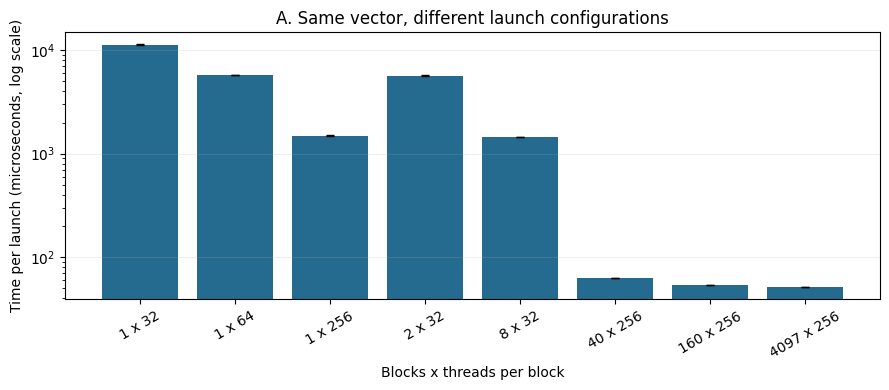

 blocks  threads  total_threads  median_ms    q25_ms    q75_ms
      1       32             32  11.370016 11.369520 11.391792
      1       64             64   5.720064  5.716256  5.720512
      1      256            256   1.497088  1.496555  1.502059
      2       32             64   5.701632  5.699408  5.704464
      8       32            256   1.440779  1.439840  1.441984
     40      256          10240   0.062460  0.062439  0.062556
    160      256          40960   0.052919  0.052903  0.052923
   4097      256        1048832   0.050898  0.050891  0.050908


In [19]:
analyze_launch.plot_a(summary)


### B. How many blocks are useful?

Follow the time as the grid grows at a fixed block size. The dashed line marks M,
the number of SMs, as a reference only. Look for a falling region, a plateau, or
a minimum followed by a rise. Several causes can coexist: more SMs in use, more
ready warps, memory throughput, caching and scheduling overhead. This is not a
direct measurement of latency hiding or occupancy.


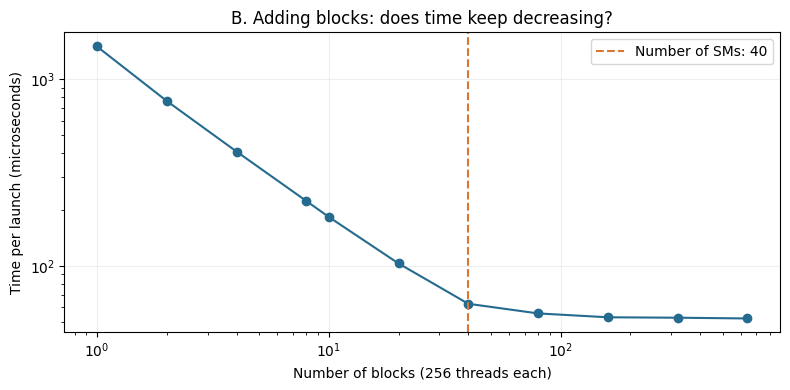

In [20]:
analyze_launch.plot_b(meta, summary)


### C. Hold the total number of threads fixed

Now even the grid stride is unchanged across configurations. Only the grouping
of threads into blocks varies. Look at the spread of the trial means as well as
their medians. The lowest observed median identifies a candidate for this
workload, not a universally optimal block size.


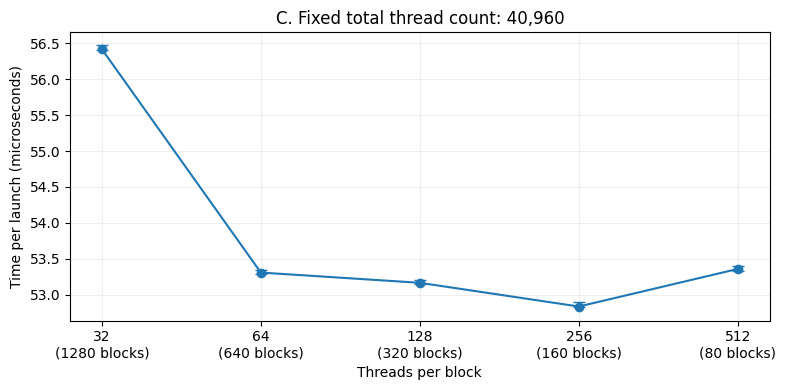

In [21]:
analyze_launch.plot_c(summary)


### D. Repeat at different vector lengths

The original one-element-per-thread launch corresponds to `ceil(N/256)` blocks;
the same grid-stride kernel can execute that launch with at most one loop iteration
per thread. Compare it with one block, M blocks and 4M blocks. For small arrays,
extra launched threads may have no elements to process.

Effective bandwidth is 12N bytes / elapsed time (two four-byte reads and one write).
It is a count of algorithmic data access, **not** measured DRAM traffic. Repeated
arrays can be cached. Keep this in mind when comparing with an advertised hardware
bandwidth or when comparing different vector lengths.


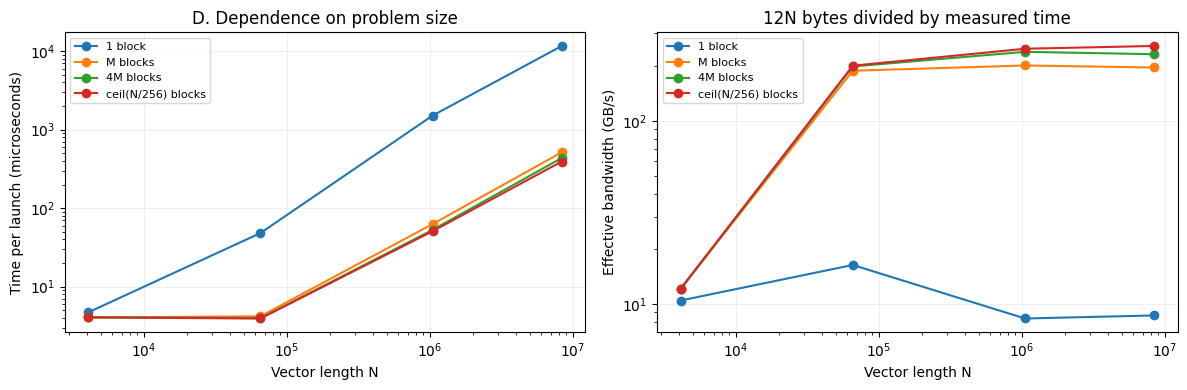

Effective bandwidth counts two float reads and one float write per element.
Repeated data can be cached: this is not measured DRAM traffic or PCIe bandwidth.
The SM count M is a reference for grid sizing, not a measured block placement.


In [22]:
analyze_launch.plot_d(meta, summary)


## 12. Generate a discussion from your results

This cell inserts only numbers calculated from this run. It records the GPU,
tested configurations and variability caveat, without inventing an architectural
cause for an observed timing difference. The LaTeX version is ready to review and
incorporate into the chapter after these plots have been examined.

Repeat the complete benchmark if differences are small or the GPU is busy.
There is no formal significance test here.


In [23]:
analyze_launch.write_report(meta, summary)


On Tesla T4 (40 SMs), Experiment A used N=1,048,579 elements. The one-block, 32-thread launch took 11370.016 microseconds, while the lowest observed median among the tested configurations was 50.898 microseconds with 4097 blocks of 256 threads. The ratio of these medians was 223.39. This compares GPU configurations, not GPU and CPU performance.

With 64 total threads, the ratio T(1 block of 64)/T(2 blocks of 32) was 1.003. The two-block configuration permits distribution across more than one SM; these timing measurements do not establish the actual SM assignment.

At 256 threads per block, Experiment B reached its lowest observed median at 640 blocks (52.166 microseconds). At the largest tested grid, 640 blocks, the median was 52.166 microseconds. The interquartile bands should be examined before interpreting small differences; they describe variability and are not confidence intervals.

Experiment C kept 40,960 total threads fixed. Among the tested partitions, 256 threads per block pr

## 13. Save a reproducible results package

The archive contains raw and summarized timings, hardware metadata, plots,
generated discussion, the CUDA sources and the unchanged original Timing archive.
Save the notebook in Drive as well: runtime files are temporary.
The download cell uses Colab's built-in API; outside Colab, use the displayed file link.


In [24]:
import zipfile
files_to_save = [Path('launch_results.csv'), Path('device.json')]
files_to_save += list(Path('results').glob('*'))
files_to_save += list(Path('code').glob('*'))
files_to_save += [Path('original/Timing.zip')]
with zipfile.ZipFile('chapter02_launch_results.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for p in files_to_save:
        if p.is_file():
            z.write(p, p.as_posix())
try:
    from google.colab import files
except ImportError:
    from IPython.display import FileLink, display
    display(FileLink('chapter02_launch_results.zip'))
else:
    files.download('chapter02_launch_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. What this experiment establishes

- Correctness does not require one thread per element: a grid-stride loop can reuse threads.
- More threads in one block cannot spread that block over several SMs.
- More blocks make more work available for distribution, but do not prescribe SM assignment.
- Timing comparisons must keep the work and measurement scope clear.
- The best observed launch can depend on both the GPU and the vector length.

These observations motivate the next book subsections on latency hiding and occupancy.
They do not prove those mechanisms in isolation.

Background: [NVIDIA grid-stride-loop discussion](https://developer.nvidia.com/blog/cuda-pro-tip-write-flexible-kernels-grid-stride-loops/)
and [CUDA event API](https://docs.nvidia.com/cuda/cuda-runtime-api/cuda_runtime_api/group__CUDART__EVENT.html).
The timing interface derives from the author's supplied `Timing.zip`;
the notebook adaptation is documented in Section 8.
